In [2756]:
import requests
import json
import math

import sys
import os
sys.path.append(os.path.abspath('..'))
from shared import generate
import time
import re

import pandas as pd
import numpy as np
from scipy.stats import ttest_rel
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests


from datetime import datetime
from zoneinfo import ZoneInfo

from concurrent.futures import ThreadPoolExecutor, as_completed
import asyncio
from pathlib import Path
from itertools import product



### Filenames, Directories, and Variables

In [2757]:


comparisons = [
    ("autistic", "no-context"),
    ("neurodivergent", "no-context"),
    ("neurodiversity-informed", "no-context"),
    ("autistic", "neurodivergent"),
]




### Cleaning Functions

In [2758]:
def extract_rating(output):
    if pd.isna(output):
        return None

    text = re.sub(r"<think>.*?</think>", "", str(output), flags=re.DOTALL).strip()
    match = re.findall(r"\b[1-5]\b", text)

    return int(match[-1]) if match else None

def add_clean(df):
    df = df.copy()
    df["clean"] = df["output"].apply(extract_rating)
    return df

def drop_incomplete(df):
    df = df.copy()

    # step 1: get row_ids where clean is NaN
    bad_ids = df.loc[df["clean"].isna(), "row_id"].unique()
    bad_rows = df[df["clean"].isna()]

    #print(bad_rows)

    # step 2: drop all rows with those row_ids
    return df[~df["row_id"].isin(bad_ids)].reset_index(drop=True)

### Visualisation and Testing Functions

In [2759]:
def pairwise_differences_autistic_dialogues(analysis_df, models):
    analysis_df["condition"] = (
        analysis_df["condition"]
        .astype(str)
        .str.strip()
        .str.lower()
    )


    models=models.keys()

    def stars_from_p(p):
        if pd.isna(p):
            return ""
        if p < 0.001:
            return "***"
        elif p < 0.01:
            return "**"
        elif p < 0.05:
            return "*"
        else:
            return ""

    rows = []

    for model in models:
        df_model = analysis_df[
            (analysis_df["model"] == model) &
            (analysis_df["source_file"] == "blunt_aut.json")
        ].copy()

        pivot = (
            df_model.pivot_table(
                index="row_id",
                columns="condition",
                values="clean",
                aggfunc="first"
            )
        )

        for cond_a, cond_b in comparisons:
            if cond_a not in pivot.columns or cond_b not in pivot.columns:
                rows.append({
                    "model": model,
                    "comparison": f"{cond_a} - {cond_b}",
                    "n": 0,
                    "mean_a": np.nan,
                    "mean_b": np.nan,
                    "mean_diff": np.nan,
                    "median_diff": np.nan,
                    "positive_diffs": np.nan,
                    "negative_diffs": np.nan,
                    "zero_diffs": np.nan,
                    "stat": np.nan,
                    "p_value": np.nan,
                })
                continue

            pair = pivot[[cond_a, cond_b]].dropna().copy()

            if pair.empty:
                rows.append({
                    "model": model,
                    "comparison": f"{cond_a} - {cond_b}",
                    "n": 0,
                    "mean_a": np.nan,
                    "mean_b": np.nan,
                    "mean_diff": np.nan,
                    "median_diff": np.nan,
                    "positive_diffs": np.nan,
                    "negative_diffs": np.nan,
                    "zero_diffs": np.nan,
                    "stat": np.nan,
                    "p_value": np.nan,
                })
                continue

            diff = pair[cond_a] - pair[cond_b]

            positive_diffs = (diff > 0).sum()
            negative_diffs = (diff < 0).sum()
            zero_diffs = (diff == 0).sum()

            nonzero_diff = diff[diff != 0]

            if len(nonzero_diff) == 0:
                stat = np.nan
                p_value = 1.0
            else:
                stat, p_value = wilcoxon(diff)

            rows.append({
                "model": model,
                "comparison": f"{cond_a} - {cond_b}",
                "n": len(diff),
                "mean_a": pair[cond_a].mean(),
                "mean_b": pair[cond_b].mean(),
                "mean_diff": diff.mean(),
                "median_diff": diff.median(),
                "positive_diffs": positive_diffs,
                "negative_diffs": negative_diffs,
                "zero_diffs": zero_diffs,
                "stat": stat,
                "p_value": p_value,
            })

    results_df = pd.DataFrame(rows)

    mask = results_df["p_value"].notna()
    results_df["p_adj"] = np.nan
    results_df.loc[mask, "p_adj"] = multipletests(
        results_df.loc[mask, "p_value"],
        method="fdr_bh"
    )[1]

    results_df["stars"] = results_df["p_adj"].apply(stars_from_p)

    results_df = results_df[
        [
            "model",
            "comparison",
            "n",
            "mean_a",
            "mean_b",
            "mean_diff",
            "median_diff",
            "positive_diffs",
            "negative_diffs",
            "zero_diffs",
            "stat",
            "p_value",
            "p_adj",
            "stars",
        ]
    ].sort_values(["model", "comparison"]).reset_index(drop=True)

    print("Comparisons within autistic dialogues. Is the difference of means statistically significant across context conditions?")

    return results_df

In [2760]:
def pairwise_differences_overall(analysis_df, models, source_map, comparisons):
    analysis_df["condition"] = (
        analysis_df["condition"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    analysis_df["source_file"] = (
        analysis_df["source_file"]
        .astype(str)
        .str.strip()
    )

    models = models.keys()


    def stars_from_p(p):
        if pd.isna(p):
            return ""
        if p < 0.001:
            return "***"
        elif p < 0.01:
            return "**"
        elif p < 0.05:
            return "*"
        return ""

    def run_paired_test(diff):
        """
        Paired Wilcoxon signed-rank test on within-item differences.

        Input:
            diff = condition_A - condition_B for matched dialogues

        Null hypothesis:
            median(diff) = 0
        """
        diff = pd.Series(diff).dropna()
        n = len(diff)
        pos = int((diff > 0).sum())
        neg = int((diff < 0).sum())
        zero = int((diff == 0).sum())

        if n == 0:
            return {
                "n": 0,
                "mean_diff": np.nan,
                "median_diff": np.nan,
                "positive_diffs": np.nan,
                "negative_diffs": np.nan,
                "zero_diffs": np.nan,
                "stat": np.nan,
                "p_value": np.nan,
            }

        if (diff != 0).sum() == 0:
            stat = np.nan
            p_value = 1.0
        else:
            stat, p_value = wilcoxon(diff)

        return {
            "n": n,
            "mean_diff": diff.mean(),
            "median_diff": diff.median(),
            "positive_diffs": pos,
            "negative_diffs": neg,
            "zero_diffs": zero,
            "stat": stat,
            "p_value": p_value,
        }

    print("=" * 100)
    print("TABLE 1: WITHIN-DATASET FRAMING EFFECTS")
    print()
    print("Research question:")
    print("Does framing (autistic / neurodivergent / no-context) change ratings WITHIN the same dataset?")
    print("This is tested separately for the autistic-dialogue dataset and the non-autistic-dialogue dataset.")
    print()
    print("Examples of comparisons:")
    print("- autistic - no-context")
    print("- neurodivergent - no-context")
    print("- autistic - neurodivergent")
    print()
    print("Null hypothesis for each row:")
    print("The median paired difference between the two conditions is 0.")
    print("That means framing has no systematic effect within that dataset.")
    print()
    print("How to interpret key columns:")
    print("- mean_a / mean_b: average rating under each condition")
    print("- mean_diff = mean(condition A - condition B)")
    print("    > 0  => condition A tends to get higher ratings")
    print("    < 0  => condition B tends to get higher ratings")
    print("- median_diff: typical paired difference; useful because ratings are discrete")
    print("- positive_diffs: number of dialogues where A > B")
    print("- negative_diffs: number of dialogues where A < B")
    print("- zero_diffs: number of dialogues where A = B")
    print("- p_adj / stars: significance after FDR correction")
    print()
    print("Big-picture interpretation:")
    print("This table tells you whether framing does anything at all within AUT or within NON.")
    print("=" * 100)

    # ----------------------------
    # 1) Within-dataset framing effects
    #    (aut vs aut across conditions)
    #    (non vs non across conditions)
    # ----------------------------
    within_rows = []

    for model in models:
        for dataset_name, source_file in source_map.items():
            df_sub = analysis_df[
                (analysis_df["model"] == model) &
                (analysis_df["source_file"] == source_file)
            ].copy()

            pivot = df_sub.pivot_table(
                index="row_id",
                columns="condition",
                values="clean",
                aggfunc="first"
            )

            for cond_a, cond_b in comparisons:
                comparison_name = f"{cond_a} - {cond_b}"

                if cond_a not in pivot.columns or cond_b not in pivot.columns:
                    within_rows.append({
                        "analysis": "within_dataset_framing",
                        "model": model,
                        "dataset": dataset_name,
                        "comparison": comparison_name,
                        "mean_a": np.nan,
                        "mean_b": np.nan,
                        **run_paired_test(pd.Series(dtype=float))
                    })
                    continue

                pair = pivot[[cond_a, cond_b]].dropna().copy()
                diff = pair[cond_a] - pair[cond_b]

                stats = run_paired_test(diff)

                within_rows.append({
                    "analysis": "within_dataset_framing",
                    "model": model,
                    "dataset": dataset_name,
                    "comparison": comparison_name,
                    "mean_a": pair[cond_a].mean() if len(pair) else np.nan,
                    "mean_b": pair[cond_b].mean() if len(pair) else np.nan,
                    **stats
                })

    within_df = pd.DataFrame(within_rows)

    mask = within_df["p_value"].notna()
    within_df["p_adj"] = np.nan
    if mask.sum() > 0:
        within_df.loc[mask, "p_adj"] = multipletests(
            within_df.loc[mask, "p_value"],
            method="fdr_bh"
        )[1]
    within_df["stars"] = within_df["p_adj"].apply(stars_from_p)

    within_df = within_df[
        [
            "analysis",
            "model",
            "dataset",
            "comparison",
            "n",
            "mean_a",
            "mean_b",
            "mean_diff",
            "median_diff",
            "positive_diffs",
            "negative_diffs",
            "zero_diffs",
            "stat",
            "p_value",
            "p_adj",
            "stars",
        ]
    ].sort_values(["model", "dataset", "comparison"]).reset_index(drop=True)

    print("WITHIN-DATASET FRAMING EFFECTS")
    display(within_df)

    print()
    print("=" * 100)
    print("TABLE 2: INTERACTION-STYLE TEST")
    print()
    print("Research question:")
    print("Does framing affect autistic dialogues differently than non-autistic dialogues?")
    print()
    print("Core idea:")
    print("First compute the framing effect within AUT.")
    print("Then compute the framing effect within NON.")
    print("Then compare those two effects.")
    print()
    print("Formula:")
    print("delta = (AUT condition A - AUT condition B) - (NON condition A - NON condition B)")
    print()
    print("Null hypothesis for each row:")
    print("The median delta is 0.")
    print("That means framing affects AUT and NON equally.")
    print()
    print("How to interpret key columns:")
    print("- mean_diff_aut: framing effect within AUT")
    print("- mean_diff_non: framing effect within NON")
    print("- mean_delta = mean_diff_aut - mean_diff_non")
    print("    > 0  => framing effect is stronger for AUT")
    print("    < 0  => framing effect is stronger for NON")
    print("    ~ 0  => framing affects both similarly")
    print("- median_delta: typical interaction effect")
    print("    0  => usually no differential effect")
    print("    1 or -1 => typical difference is about one rating point")
    print("- positive_deltas: cases where AUT shows a stronger framing effect")
    print("- negative_deltas: cases where NON shows a stronger framing effect")
    print("- zero_deltas: cases where framing affected AUT and NON equally")
    print("- p_adj / stars: significance after FDR correction")
    print()
    print("Big-picture interpretation:")
    print("This is the main bias table.")
    print("It tells you whether framing creates a differential effect across AUT vs NON dialogues.")
    print("=" * 100)

    # ----------------------------
    # 2) Interaction-style test
    #    Compare framing effect in aut vs non:
    #    delta = (aut_condA - aut_condB) - (non_condA - non_condB)
    #    Test whether delta differs from 0
    # ----------------------------
    interaction_rows = []

    for model in models:
        df_model = analysis_df[analysis_df["model"] == model].copy()

        aut_df = df_model[df_model["source_file"] == source_map["aut"]].copy()
        non_df = df_model[df_model["source_file"] == source_map["non"]].copy()

        aut_pivot = aut_df.pivot_table(
            index="row_id",
            columns="condition",
            values="clean",
            aggfunc="first"
        )
        non_pivot = non_df.pivot_table(
            index="row_id",
            columns="condition",
            values="clean",
            aggfunc="first"
        )

        for cond_a, cond_b in comparisons:
            comparison_name = f"{cond_a} - {cond_b}"

            if (
                cond_a not in aut_pivot.columns or cond_b not in aut_pivot.columns or
                cond_a not in non_pivot.columns or cond_b not in non_pivot.columns
            ):
                interaction_rows.append({
                    "analysis": "interaction_framing_by_dataset",
                    "model": model,
                    "comparison": comparison_name,
                    "mean_diff_aut": np.nan,
                    "mean_diff_non": np.nan,
                    **run_paired_test(pd.Series(dtype=float))
                })
                continue

            aut_pair = aut_pivot[[cond_a, cond_b]].dropna().copy()
            aut_pair["diff_aut"] = aut_pair[cond_a] - aut_pair[cond_b]

            non_pair = non_pivot[[cond_a, cond_b]].dropna().copy()
            non_pair["diff_non"] = non_pair[cond_a] - non_pair[cond_b]

            merged = (
                aut_pair[["diff_aut"]]
                .join(non_pair[["diff_non"]], how="inner")
                .dropna()
            )

            delta = merged["diff_aut"] - merged["diff_non"]
            stats = run_paired_test(delta)

            interaction_rows.append({
                "analysis": "interaction_framing_by_dataset",
                "model": model,
                "comparison": comparison_name,
                "mean_diff_aut": merged["diff_aut"].mean() if len(merged) else np.nan,
                "mean_diff_non": merged["diff_non"].mean() if len(merged) else np.nan,
                **stats
            })

    interaction_df = pd.DataFrame(interaction_rows)

    mask = interaction_df["p_value"].notna()
    interaction_df["p_adj"] = np.nan
    if mask.sum() > 0:
        interaction_df.loc[mask, "p_adj"] = multipletests(
            interaction_df.loc[mask, "p_value"],
            method="fdr_bh"
        )[1]
    interaction_df["stars"] = interaction_df["p_adj"].apply(stars_from_p)

    interaction_df = interaction_df[
        [
            "analysis",
            "model",
            "comparison",
            "n",
            "mean_diff_aut",
            "mean_diff_non",
            "mean_diff",
            "median_diff",
            "positive_diffs",
            "negative_diffs",
            "zero_diffs",
            "stat",
            "p_value",
            "p_adj",
            "stars",
        ]
    ].rename(columns={
        "mean_diff": "mean_delta",
        "median_diff": "median_delta",
        "positive_diffs": "positive_deltas",
        "negative_diffs": "negative_deltas",
        "zero_diffs": "zero_deltas",
    }).sort_values(["model", "comparison"]).reset_index(drop=True)

    print("INTERACTION-STYLE TEST: DOES FRAMING AFFECT AUT DIFFERENTLY THAN NON?")
    display(interaction_df)

    print()
    print("=" * 100)
    print("SUMMARY OF WHAT EACH TABLE IS FOR")
    print()
    print("Table 1: Establishes whether framing changes ratings within AUT or within NON.")
    print("Table 2: Tests whether that framing effect differs across AUT vs NON.")
    print()
    print("How to use them together:")
    print("- If Table 1 is significant in both datasets, framing has a general effect.")
    print("- If Table 2 is also significant, framing does not affect both datasets equally.")
    print("- If Table 2 is not significant, framing may be a general effect rather than a dataset-specific bias.")
    print("=" * 100)

    # ----------------------------
    # Optional combined table
    # ----------------------------
    # all_results_df = pd.concat([within_df, interaction_df], axis=0, ignore_index=True)
    # all_results_df

In [2761]:

def pairwise_visualise(analysis_df, models, conditions_to_plot, baseline_file_name, task):
    n_models = len(models)
    ncols = 3
    nrows = math.ceil(n_models / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(14, 3 * nrows),
        sharex=True, sharey=True
    )
    axes = np.atleast_1d(axes).flatten()

    for i, model in enumerate(models):
        ax = axes[i]

        df_sub = analysis_df[analysis_df["model"] == model]

        non = df_sub[
            (df_sub["condition"] == "no-context") &
            (df_sub["source_file"] == baseline_file_name)
        ]
        non_pivot = (
            non.pivot_table(index="row_id", values="clean", aggfunc="first")
               .rename(columns={"clean": "clean_non"})
        )

        bins = np.arange(-4.5, 5.5, 1)
        centers = bins[:-1] + 0.5
        n_series = len(conditions_to_plot)
        width = 0.15
        offsets = np.linspace(
            -(n_series - 1) / 2 * width,
            (n_series - 1) / 2 * width,
            n_series
        )

        legend_handles = []

        for k, (cond, color, label_text) in enumerate(conditions_to_plot):
            aut = df_sub[
                (df_sub["condition"] == cond) &
                (df_sub["source_file"] == "blunt_aut.json")
            ]

            aut_pivot = (
                aut.pivot_table(index="row_id", values="clean", aggfunc="first")
                   .rename(columns={"clean": "clean_aut"})
            )

            pivot = aut_pivot.join(non_pivot).dropna()

            if pivot.empty:
                continue

            pivot["diff"] = pivot["clean_aut"] - pivot["clean_non"]
            data = pivot["diff"].values

            counts, _ = np.histogram(data, bins=bins)

            ax.bar(
                centers + offsets[k],
                counts,
                width=width,
                color=color,
                alpha=0.3,
                edgecolor=color,
                linewidth=1.2
            )

            # if len(data) > 1 and np.std(data) > 0:
            #     kde = gaussian_kde(data)
            #     x_vals = np.linspace(-4, 4, 200)
            #     y_vals = kde(x_vals) * len(data)
            #     ax.plot(x_vals, y_vals, color=color)

            mean_val = np.mean(data)

            if len(data) > 0 and np.any(data != 0):
                stat, p = wilcoxon(data)
            else:
                p = 1.0

            def get_stars(p):
                if p < 0.001:
                    return "***"
                elif p < 0.01:
                    return "**"
                elif p < 0.05:
                    return "*"
                return ""

            stars = get_stars(p)

            legend_handles.append(
                Patch(
                    facecolor=color,
                    alpha=0.3,
                    edgecolor=color,
                    #label=f"{label_text}: μ={mean_val:.2f}, p={p:.3f} {stars}"
                    label=f"{label_text}: μ={mean_val:.2f} {stars}"
                )
            )

        if legend_handles:
            ax.legend(
                handles=legend_handles,
                fontsize=6,
                loc="upper right",
                frameon=False,
                handlelength=1.5,
                labelspacing=0.3,
                borderpad=0.2
            )

        ax.set_title(model)
        ax.set_xticks(range(-4, 5))
        ax.tick_params(axis="x", labelbottom=True)
        ax.set_xlabel("Rating Difference")

        if i % ncols == 0:
            ax.set_ylabel("Frequency")

    # hide unused subplots
    for j in range(n_models, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(
        f"Pairwise Differences in {task} Across Context Conditions",
        fontsize=14,
        y=0.98
    )

    print("For non-aut dialogues, condition is set to no-context.\nSmaller absolute differences are better.")

    plt.tight_layout(rect=[0.05, 0.05, 1, 0.96])
    plt.show()

### Final Graphs

In [2762]:
def calculate_differences(df,source_map,baseline_condition,value_col):
    aut_file = source_map["aut"]
    non_aut_file = source_map["non"]
    aut = df[df["source_file"] == aut_file].copy()
    non_aut = df[df["source_file"] == non_aut_file].copy()

    baseline = non_aut[non_aut["condition"] == baseline_condition][
        ["row_id", "model", value_col]
    ].copy()

    baseline = baseline.rename(columns={value_col: "baseline_clean"})

    merged = aut.merge(baseline, on=["row_id", "model"], how="inner")

    merged["diff"] = merged[value_col] - merged["baseline_clean"]

    return merged

In [2763]:
def agg_means(df, attribute_list, value):
    agg = (
        df
        .groupby(attribute_list)[value]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    # standard error
    import numpy as np
    agg["se"] = agg["std"] / np.sqrt(agg["count"])

    return agg

In [2764]:
def compute_baseline_significance(df, source_map, value_col="clean"):
    """
    Tests whether each condition differs from baseline.

    Baseline = blunt_non_aut + no-context
    """

    aut_file = source_map["aut"]
    non_aut_file = source_map["non"]

    results = []

    for model in df["model"].unique():
        df_model = df[df["model"] == model]

        baseline = df_model[
            (df_model["source_file"] == non_aut_file) &
            (df_model["condition"] == "no-context")
        ][["row_id", value_col]]

        for cond in ["no-context", "autistic", "neurodivergent", "neurodiversity-informed"]:

            cond_df = df_model[
                (df_model["source_file"] == aut_file) &
                (df_model["condition"] == cond)
            ][["row_id", value_col]]

            merged = baseline.merge(cond_df, on="row_id", suffixes=("_base", "_cond"))

            if len(merged) < 10 or (merged[f"{value_col}_base"] - merged[f"{value_col}_cond"]).nunique() <= 1:
                p = 1.0
            else:
                try:
                    stat, p = wilcoxon(
                        merged[f"{value_col}_base"],
                        merged[f"{value_col}_cond"]
                    )
                except:
                    p = 1.0

            results.append({
                "model": model,
                "condition": cond,
                "p_value": p
            })

    sig_df = pd.DataFrame(results)

    # multiple testing correction
    sig_df["p_adj"] = multipletests(sig_df["p_value"], method="fdr_bh")[1]
    sig_df["significant"] = sig_df["p_adj"] < 0.05

    return sig_df

In [2765]:
def plot_condition_means(agg, orig_models,task):
    import matplotlib.pyplot as plt
    import numpy as np

    condition_order = [
        "no-context",
        "autistic",
        "neurodivergent",
        "neurodiversity-informed"
    ]

    conditions = [c for c in condition_order if c in agg["condition"].unique()]

    # sort only among models present in agg, then keep only those requested
    sorted_models = (
        agg.groupby("model")["mean"]
        .mean()
        .sort_values()
        .index.tolist()
    )

    models = [model for model in sorted_models if model in orig_models]

    x_positions = np.arange(len(models))
    offsets = np.linspace(-0.25, 0.25, len(conditions))

    color_map = {
    "no-context": "black",
    "autistic": "blue",
    "neurodivergent": "green",
    "neurodiversity-informed": "red"
    }

    marker_map = {
        "no-context": "x",
        "autistic": "o",
        "neurodivergent": "^",
        "neurodiversity-informed": "s"
    }

    label_map = { "no-context": "No context", "autistic": "Autistic", "neurodivergent": "Neurodivergent", "neurodiversity-informed": "ND-informed" }

    plt.figure(figsize=(11, 6))

    for i, cond in enumerate(conditions):
        subset = agg[agg["condition"] == cond].copy()
        subset = subset.set_index("model").reindex(models).reset_index()

        plt.errorbar(
            x_positions + offsets[i],
            subset["mean"],
            yerr=subset["se"],
            fmt=marker_map[cond],
            color=color_map[cond],
            ecolor=color_map[cond],
            capsize=3,
            markersize=6,
            linewidth=1,
            label=label_map.get(cond, cond)
        )

    plt.grid(axis='y', linestyle='--', alpha=0.3)

    for x in x_positions:
        plt.axvline(x, color='gray', alpha=0.08)

    plt.xticks(x_positions, models, rotation=45, ha="right", fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel("Model", fontsize = 10)
    plt.ylabel("Mean Difference (autistic-nonautistic)", fontsize = 10)
    plt.title(f"Mean Difference in {task} by Model and Condition")
    plt.legend(title="Condition", frameon=False, loc = "center left", bbox_to_anchor = (1.02,0.5))

    plt.tight_layout()
    plt.show()

### Main

#### Decision Making

In [2766]:
task = "hireability-ratings"
dataset = "bluntness"
jobs_file = f"{dataset}-{task}.csv"

source_map = {
    "aut": "blunt_aut.json",
    "non": "blunt_non_aut.json",
}

In [2767]:
# task = "hireability-ratings"
# dataset = "figurative"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "figurative_aut.json",
#     "non": "figurative_non_aut.json",
# }

In [2768]:
# task = "hireability-ratings"
# dataset = "indirect"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "indirect_aut.json",
#     "non": "indirect_non_aut.json",
# }

In [2769]:
# task = "dating-ratings"
# dataset = "bluntness"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "blunt_aut.json",
#     "non": "blunt_non_aut.json",
# }

In [2770]:
# task = "dating-ratings"
# dataset = "figurative"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "figurative_aut.json",
#     "non": "figurative_non_aut.json",
# }

In [2771]:
# task = "dating-ratings"
# dataset = "indirect"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "indirect_aut.json",
#     "non": "indirect_non_aut.json",
# }

In [2772]:
# task = "admission-ratings"
# dataset = "bluntness"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "blunt_aut.json",
#     "non": "blunt_non_aut.json",
# }

In [2773]:
# task = "admission-ratings"
# dataset = "figurative"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "figurative_aut.json",
#     "non": "figurative_non_aut.json",
# }

In [2774]:
# task = "admission-ratings"
# dataset = "indirect"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "indirect_aut.json",
#     "non": "indirect_non_aut.json",
# }

In [2775]:
# task = "triage-ratings"
# dataset = "bluntness"
# jobs_file = f"backup/{dataset}-{task}-backup.csv"

# source_map = {
#     "aut": "blunt_aut.json",
#     "non": "blunt_non_aut.json",
# }

In [2776]:
# task = "clinician-ratings"
# dataset = "bluntness"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "blunt_aut.json",
#     "non": "blunt_non_aut.json",
# }

In [2777]:
# task = "plausible-ratings"
# dataset = "bluntness"
# jobs_file = f"backup/{dataset}-{task}-backup.csv"

# source_map = {
#     "aut": "blunt_aut.json",
#     "non": "blunt_non_aut.json",
# }

#### Traits

In [2778]:
# task = "clarity-ratings"
# dataset = "bluntness"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "blunt_aut.json",
#     "non": "blunt_non_aut.json",
# }

In [2779]:
# task = "politeness-ratings"
# dataset = "bluntness"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "blunt_aut.json",
#     "non": "blunt_non_aut.json",
# }

In [2780]:
# task = "honesty-ratings"
# dataset = "bluntness"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "blunt_aut.json",
#     "non": "blunt_non_aut.json",
# }

In [2781]:
# task = "language-ratings"
# dataset = "bluntness"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "blunt_aut.json",
#     "non": "blunt_non_aut.json",
# }

## Analysis

In [2782]:
models = {
    'llama3.2-1b': 'us.meta.llama3-2-1b-instruct-v1:0',
    'gpt4o-mini': '4o-mini',
    'gemini2.5-flash': 'gemini-2.5-flash',
    'sonnet4.5': 'us.anthropic.claude-sonnet-4-5-20250929-v1:0',
    'haiku4.5': 'us.anthropic.claude-haiku-4-5-20251001-v1:0',
    'gpt4o': 'gpt-4o',
    'llama3.3-70b': 'azure-llama3.3-70b',
    'gpt5.2': 'gpt-5.2',
    'deepseek-r1': 'azure-deepseek-r1',
}

In [2783]:
df = pd.read_csv(jobs_file)
print(len(df))
df = df[df["model"] != "sonnet4.5"]
df = df[df["model"] != "haiku4.5"]
df = df[df["model"] != "llama3.2-1b"]
print(len(df))
clean_df = add_clean(df)    
print(len(df))
analysis_df = drop_incomplete(clean_df)
print(len(analysis_df))



7200
4800
4800
4704


In [2784]:
def plot_condition_means(agg, orig_models, task, sig_df=None):
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    condition_order = [
        "no-context",
        "autistic",
        "neurodivergent",
        "neurodiversity-informed"
    ]

    conditions = [c for c in condition_order if c in agg["condition"].unique()]

    sorted_models = (
        agg.groupby("model")["mean"]
        .mean()
        .sort_values()
        .index.tolist()
    )

    models = [model for model in sorted_models if model in orig_models]

    x_positions = np.arange(len(models))
    offsets = np.linspace(-0.25, 0.25, len(conditions))

    color_map = {
        "no-context": "black",
        "autistic": "blue",
        "neurodivergent": "green",
        "neurodiversity-informed": "red"
    }

    marker_map = {
        "no-context": "x",
        "autistic": "o",
        "neurodivergent": "^",
        "neurodiversity-informed": "s"
    }

    label_map = {
        "no-context": "No context",
        "autistic": "Autistic",
        "neurodivergent": "Neurodivergent",
        "neurodiversity-informed": "ND-informed"
    }

    plt.figure(figsize=(11, 6))

    for i, cond in enumerate(conditions):
        subset = agg[agg["condition"] == cond].copy()
        subset = subset.set_index("model").reindex(models).reset_index()

        plt.errorbar(
            x_positions + offsets[i],
            subset["mean"],
            yerr=subset["se"],
            fmt=marker_map[cond],
            color=color_map[cond],
            ecolor=color_map[cond],
            capsize=3,
            markersize=6,
            linewidth=1,
            label=label_map.get(cond, cond)
        )

        # add significance stars relative to fixed baseline
        if sig_df is not None:
            sig_subset = sig_df[sig_df["condition"] == cond].copy()
            sig_subset = sig_subset.set_index("model").reindex(models).reset_index()

            for j, row in sig_subset.iterrows():
                if pd.notna(row["significant"]) and bool(row["significant"]):
                    y = subset.loc[j, "mean"]
                    err = subset.loc[j, "se"] if pd.notna(subset.loc[j, "se"]) else 0

                    plt.text(
                        x_positions[j] + offsets[i],
                        y + err + 0.04,
                        "*",
                        color=color_map[cond],
                        ha="center",
                        va="bottom",
                        fontsize=14,
                        fontweight="bold"
                    )

    plt.grid(axis='y', linestyle='--', alpha=0.3)

    for x in x_positions:
        plt.axvline(x, color='gray', alpha=0.08)

    plt.xticks(x_positions, models, rotation=45, ha="right", fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel("Model", fontsize=10)
    plt.ylabel("Mean Difference (baseline - condition)", fontsize=10)
    plt.title(f"Mean Difference in {task} by Model and Condition")

    plt.legend(
        title="Condition",
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5)
    )

    plt.tight_layout()
    plt.show()

In [2800]:
def plot_differences(source_map, task, baseline = "no-context", diff_value = "clean", agg_value = "diff"):
    merged = calculate_differences(analysis_df, source_map, baseline, diff_value)
    #print(len(merged[merged['model_id']=='us.anthropic.claude-sonnet-4-5-20250929-v1:0']))
    print(len(merged))
    agg = agg_means(merged, ["model","condition"], agg_value)
    print("Min row:")
    print(agg.loc[agg["mean"].idxmin()])

    print("\nMax row:")
    print(agg.loc[agg["mean"].idxmax()])

    #print(agg)
    #plot_condition_means(agg, models, task)
    sig_df = compute_baseline_significance(analysis_df,source_map)
    plot_condition_means(agg, models, task=task, sig_df=sig_df)
    
    

2352
Min row:
model        gemini2.5-flash
condition         no-context
mean               -1.163265
std                 1.145982
count                     98
se                  0.115762
Name: 7, dtype: object

Max row:
model        gemini2.5-flash
condition           autistic
mean                0.357143
std                 1.203517
count                     98
se                  0.121574
Name: 4, dtype: object


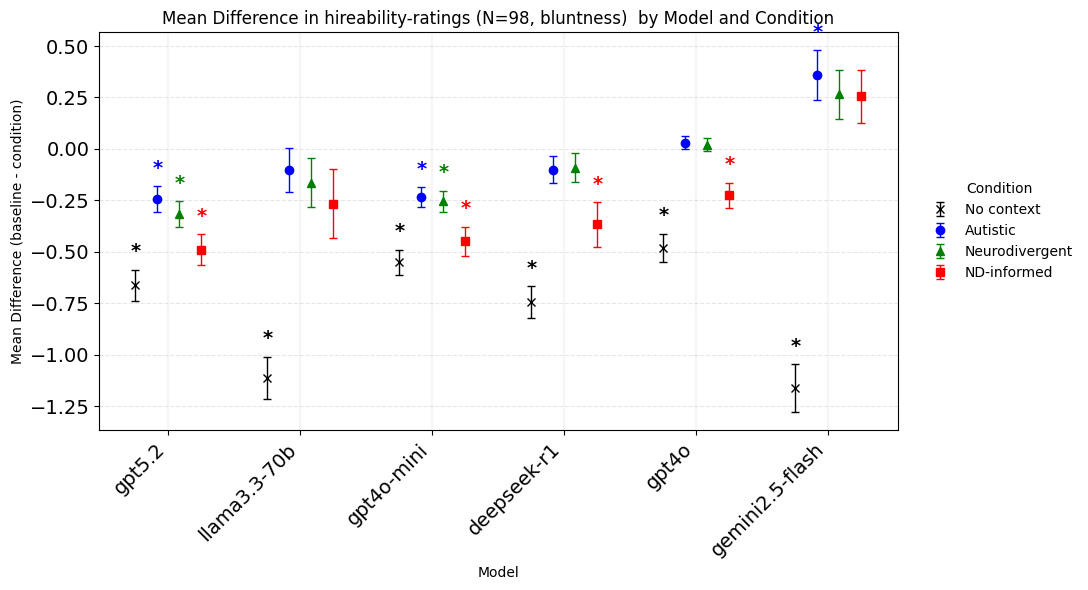

In [2801]:
plot_differences(source_map = source_map, task = task + " (N=98, " + dataset + ") ")

## Visualisations

In [125]:
analysis_df.groupby("model")["clean"].describe()

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
deepseek-r1,704.0,2.505682,0.989258,1.0,2.0,3.0,3.0,4.0
gemini2.5-flash,704.0,2.592330,1.216294,1.0,1.0,3.0,4.0,5.0
gpt4o,704.0,2.548295,1.019272,1.0,2.0,3.0,3.0,5.0
gpt4o-mini,704.0,2.571023,1.106330,1.0,2.0,3.0,4.0,4.0
gpt5.2,704.0,2.694602,1.067654,1.0,2.0,3.0,4.0,4.0
haiku4.5,704.0,2.526989,1.078358,1.0,2.0,2.0,3.0,4.0
llama3.2-1b,704.0,1.995739,0.065186,1.0,2.0,2.0,2.0,2.0
llama3.3-70b,704.0,2.600852,1.184802,1.0,1.0,3.0,4.0,5.0
sonnet4.5,704.0,2.697443,1.020804,1.0,2.0,3.0,4.0,4.0


In [20]:
# pairwise_differences_autistic_dialogues(analysis_df, models)

In [21]:
# pairwise_differences_overall(analysis_df, models, source_map, comparisons)

For non-aut dialogues, condition is set to no-context.
Smaller absolute differences are better.


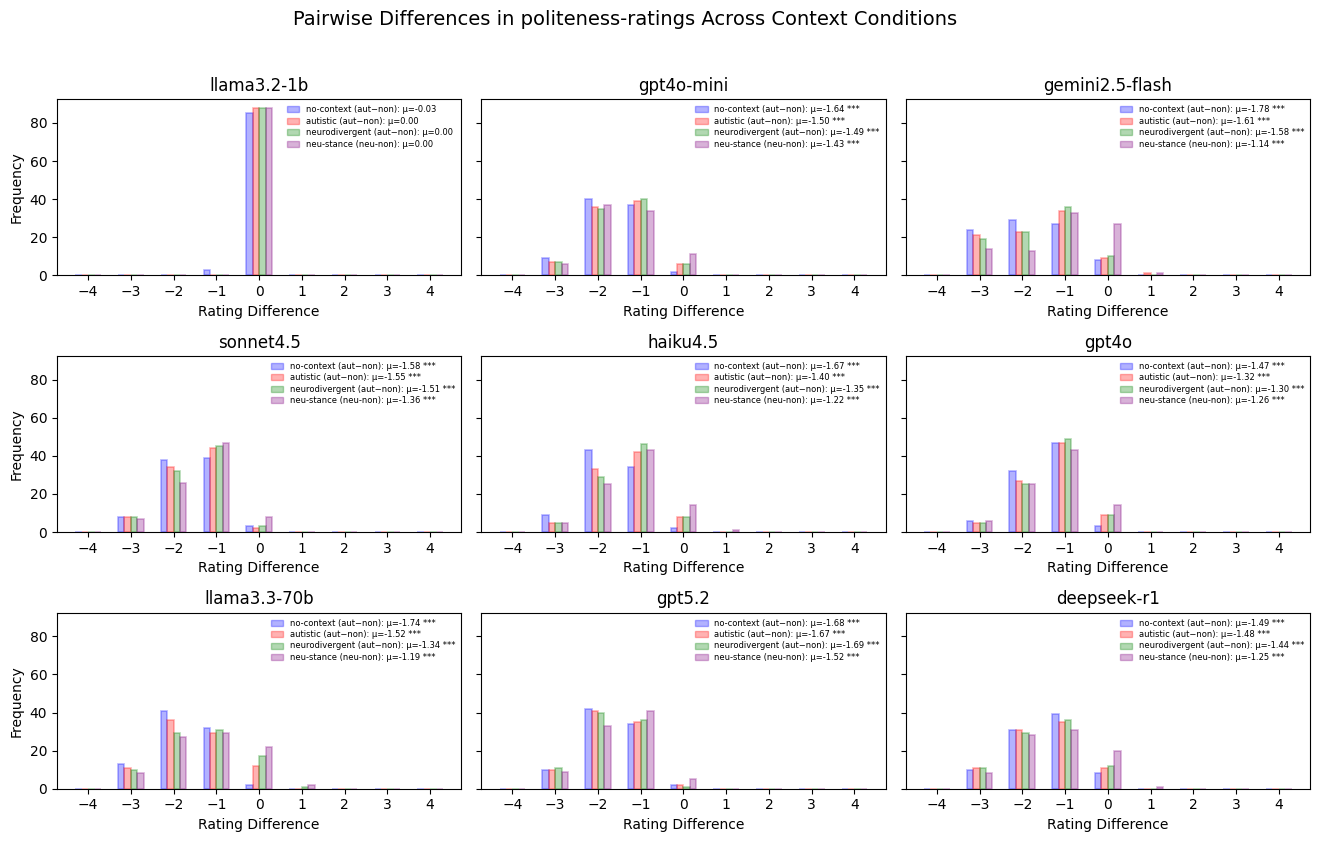

In [559]:

conditions_to_plot = [
    ("no-context", "blue", "no-context (aut−non)"),
    ("autistic", "red", "autistic (aut−non)"),
    ("neurodivergent", "green", "neurodivergent (aut−non)"),
    ("neurodiversity-informed", "purple", "neu-stance (neu-non)")
]
baseline_file_name = "blunt_non_aut.json"
pairwise_visualise(analysis_df, models.keys(), conditions_to_plot, baseline_file_name, task)